# NLP interface & Solver basics

THis tutorial illustrates the generic NLP interface, access to a solver, and plotting the traces.

In [13]:
import optsam as op
import numpy as np
import matplotlib.pyplot as plt

Define a problem, here: 2 dimensional, with 2 SOS features, and bounds [-1,-2]x[2,3]

In [14]:
class MyNLP:
    def __init__(self):
        self.dimension = 2
        self.types = [op.OT.sos] * 2
        self.bounds = np.array([[-2,-1], [2,3]])
        
        self.b = 3

    def evaluate(self, x):
        phi = np.array([ x[0]-1,
                         self.b*(x[1]-x[0]**2) ])
        J = np.array([[ 1, 0 ],
                      [ -2*self.b*x[0], self.b ]])
        return phi, J
    
nlp = MyNLP()

Create a solver

In [15]:
sol = op.NLP_Solver()
sol.setPyProblem(nlp)
sol.setOptions(stepMax=.5, damping=1e-4)
sol.setTracing(trace_x=True, trace_errs=True)

Call the solver. Here 20 times in a row, each time automatically initialized with uniform in the bounds (default implementation of nlp.getInitializationSample)

In [16]:
trace_x = []
trace_err = []

for i in range(20):
    ret = sol.solve(1)
    print(ret)

    trace_x.append(sol.getTrace_x())
    trace_err.append(sol.getTrace_errs())
    sol.clearTracing()

trace_f = [np.sum(E, axis=1) for E in trace_err]

{ time: 0.00025, evals: 9, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 4.47236e-12, f: 0, x-dim: [2] }
{ time: 7.7e-05, evals: 5, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 1.25704e-13, x-dim: [2] }
{ time: 0.000145, evals: 11, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 4.91618e-12, x-dim: [2] }
{ time: 0.000168, evals: 13, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 1.21774e-12, x-dim: [2] }
{ time: 8.8e-05, evals: 7, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 2.11491e-13, x-dim: [2] }
{ time: 0.000105, evals: 8, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 3.02596e-08, x-dim: [2] }
{ time: 5.3e-05, evals: 4, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 5.41543e-06, x-dim: [2] }
{ time: 0.000125, evals: 10, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 7.43386e-14, x-dim: [2] }
{ time: 0.000137, evals: 11, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, f: 2.49565e-14, x-dim: [2] }
{ time: 8.8e-05, evals: 7, done: 1, feasible: 1, eq: 0, ineq: 0, sos: 0, 

The following creates a grid X of input points, and evaluates the fct on X

In [17]:
nlp = sol.getProblem()
B = nlp.bounds
X = [None] * nlp.dimension
for i in range(nlp.dimension):
    X[i] = np.linspace(B[0][i], B[1][i], 30)
X = np.stack(np.meshgrid(*X, indexing='ij'), axis=-1) 
fX = np.array([nlp.eval_scalar(x)[0] for x in X.reshape(-1, nlp.dimension)])
fX = fX.reshape(X.shape[:-1])

... to prepare plotting.

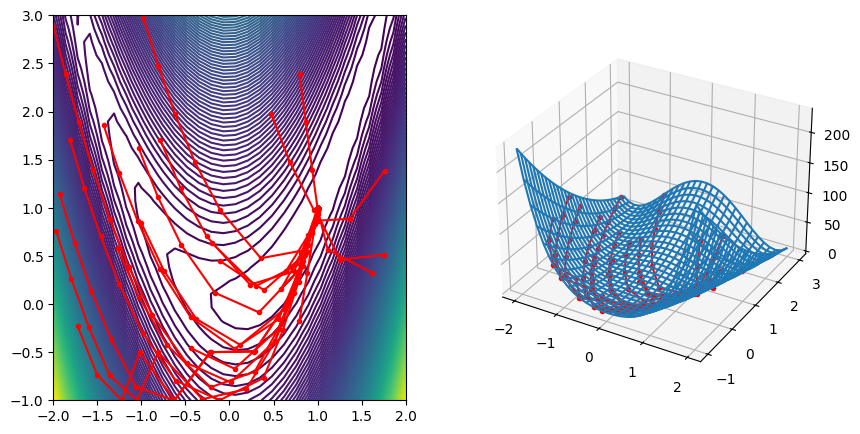

In [18]:
fig = plt.figure(figsize=(10,5))
ax1 = fig.add_subplot(121)
ax1.contour(X[:,:,0], X[:,:,1], fX, 200)
for x in trace_x:
    ax1.plot(x[:,0], x[:,1], 'o-r', ms=3)

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot_wireframe(X[:,:,0], X[:,:,1], fX)
for x,f in zip(trace_x, trace_f):
    ax2.plot(x[:,0], x[:,1], f, 'o-r', ms=3)

plt.show()

Finally, an example to check the derivatives (Jacobian of all problem features) at random initialization points:

In [19]:
for i in range(20):
    x = sol.getProblem().getInitializationSample()
    r = sol.getProblem().checkJacobian(x, 1e-6)
    # print(r, x)

checkJacobian -- SUCCESS (max diff error=4.77775e-08)
checkJacobian -- SUCCESS (max diff error=7.22076e-08)
checkJacobian -- SUCCESS (max diff error=5.4158e-08)
checkJacobian -- SUCCESS (max diff error=1.46638e-07)
checkJacobian -- SUCCESS (max diff error=9.7298e-08)
checkJacobian -- SUCCESS (max diff error=4.3091e-08)
checkJacobian -- SUCCESS (max diff error=7.05854e-08)
checkJacobian -- SUCCESS (max diff error=4.06059e-08)
checkJacobian -- SUCCESS (max diff error=1.82324e-08)
checkJacobian -- SUCCESS (max diff error=1.82324e-08)
checkJacobian -- SUCCESS (max diff error=2.94674e-08)
checkJacobian -- SUCCESS (max diff error=4.28127e-08)
checkJacobian -- SUCCESS (max diff error=6.64386e-08)
checkJacobian -- SUCCESS (max diff error=7.41691e-08)
checkJacobian -- SUCCESS (max diff error=1.82324e-08)
checkJacobian -- SUCCESS (max diff error=8.45106e-08)
checkJacobian -- SUCCESS (max diff error=2.74902e-08)
checkJacobian -- SUCCESS (max diff error=3.61076e-08)
checkJacobian -- SUCCESS (max d